# Bayes-Consistent vs Non-Consistent Protocols

This notebook demonstrates the importance of **Bayes-consistency** in experimental protocols, as defined in the paper "Epistemic Frontiers".

## Definition (Bayes-Consistency)

A protocol $\mathsf{P}$ is **Bayes-consistent** if empirical metrics converge to their population counterparts:

$$\widehat{\Delta}_{\mathsf{P},n,j} \xrightarrow[n\to\infty]{p} \Delta_j^{\ast}$$

where $\Delta_j^{\ast} = I(Y; X_j \mid \mathbf{X}_{\setminus j})$ under log-loss.

## Key Insight

**Not all experimental protocols are Bayes-consistent.** A protocol that is not Bayes-consistent can produce "evidence" of information where none exists, violating the epistemic interpretability of the experiment.

## This Notebook

We compare **three protocols** for estimating the swap delta $\widetilde{\Delta}_S = I(Y; \mathbf{X}_S) - I(Y; \mathbf{X}_S^{\mathrm{null}})$:

| Protocol | Resampling | Bayes-Consistent? | Why? |
|----------|------------|-------------------|------|
| **Bootstrap** | With replacement from $D_n$ | NO | Amplifies spurious correlations |
| **K-Fold CV** | Without replacement from $D_n$ | Partially | Uses all data, no amplification, but fixed $D_n$ |
| **DGP Realizations** | Fresh samples from $P^n$ | YES | True i.i.d. samples |

We show that bootstrap inflates $\widetilde{\Delta}$ for noise variables, K-Fold is intermediate, and DGP realizations correctly estimate $\widetilde{\Delta} \approx 0$.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from scipy import stats

# Reproducibility
seed = 42
np.random.seed(seed)


## Data Generating Process (DGP)

We use a simple DGP where:
- $X_1 \sim \mathcal{N}(0, 1)$: **Informative** variable
- $Y = \text{sign}(X_1) + \epsilon$: Target depends on $X_1$
- $Z_1, Z_2, Z_3 \sim \mathcal{N}(0, 1)$: **Noise** variables (independent of $Y$)

**Population truth:**
- $I(Y; X_1) > 0$ (informative)
- $I(Y; Z_j) = 0$ for all $j$ (noise)


In [16]:
from sklearn.feature_selection import mutual_info_classif

def generate_dgp(n=5000, p_noise=3, seed=0):
    """Generate data from a simple DGP.
    
    X_1: Informative variable (Y depends on it)
    Z_1, ..., Z_k: Noise variables (independent of Y)
    
    Y = 1 if X_1 > 0, else 0 (with some noise)
    """
    rng = np.random.default_rng(seed)
    
    # Informative variable
    X_1 = rng.normal(0, 1, n)
    
    # Target: depends on X_1 with some noise
    prob_y = 1 / (1 + np.exp(-2 * X_1))  # Logistic function
    Y = (rng.random(n) < prob_y).astype(int)
    
    # Noise variables (independent of Y by construction)
    Z = rng.normal(0, 1, size=(n, p_noise))
    
    # Combine
    X = np.column_stack([X_1, Z])
    feature_names = [r"$X_1$"] + [rf"$Z_{{{i+1}}}$" for i in range(p_noise)]
    
    return X, Y, feature_names


def compute_mi(X_j, y, random_state=0):
    """Estimate MI using sklearn's mutual_info_classif (KNN-based, Kraskov estimator).
    
    This is more robust than custom cross-entropy approaches,
    especially for smaller sample sizes in K-Fold.
    """
    if X_j.ndim == 1:
        X_j = X_j.reshape(-1, 1)
    
    mi = mutual_info_classif(
        X_j, y, 
        discrete_features=False,
        n_neighbors=5,
        random_state=random_state
    )
    return float(mi[0])


def create_null_copy(X, rng):
    """Permute rows to break X-Y association."""
    perm_idx = rng.permutation(len(X))
    return X[perm_idx] if X.ndim > 1 else X[perm_idx]


# Generate a single dataset for bootstrap protocol
n_samples = 5000  # Increased for better K-Fold stability
p_noise = 3
X_fixed, Y_fixed, feature_names = generate_dgp(n=n_samples, p_noise=p_noise, seed=seed)

print(f"Dataset: n={n_samples}, p={len(feature_names)}")
print(f"Features: {feature_names}")
print(f"Y distribution: {np.mean(Y_fixed):.2%} positive")

# Verify MI estimation works
print("\nMI verification (should show X1 > 0, Z_j ≈ 0):")
for j, fname in enumerate(feature_names):
    mi = compute_mi(X_fixed[:, j], Y_fixed, random_state=seed)
    label = "INFORMATIVE" if j == 0 else "noise"

    if j == 0:
        rng_diag = np.random.default_rng(seed)
        x_j_null = create_null_copy(X_fixed[:, j], rng_diag)
        mi_null = compute_mi(x_j_null, Y_fixed, random_state=seed)
        delta = mi - mi_null
        print(
            f"  {fname}: MI = {mi:.6f}, MI_null = {mi_null:.6f}, Δ = {delta:.6f} ({label})"
        )
    else:
        print(f"  {fname}: MI = {mi:.6f} ({label})")


Dataset: n=5000, p=4
Features: ['$X_1$', '$Z_{1}$', '$Z_{2}$', '$Z_{3}$']
Y distribution: 49.62% positive

MI verification (should show X1 > 0, Z_j ≈ 0):
  $X_1$: MI = 0.227494, MI_null = 0.000000, Δ = 0.227494 (INFORMATIVE)
  $Z_{1}$: MI = 0.000000 (noise)
  $Z_{2}$: MI = 0.009557 (noise)
  $Z_{3}$: MI = 0.000000 (noise)


In [17]:
# Cell removed - MI verification is now in the previous cell


## Protocol 1: Bootstrap (NOT Bayes-Consistent)

Bootstrap resamples **with replacement** from a fixed dataset $D_n$. 

**Problem:** Resampling creates **spurious correlations** between noise variables and $Y$ that don't exist in population. When we permute to create the null, we destroy these spurious correlations, leading to $\widetilde{\Delta} > 0$ even for noise.


In [18]:
def run_bootstrap_protocol(X, y, feature_names, n_bootstrap=50, seed=42):
    """Protocol 1: Bootstrap (NOT Bayes-consistent).
    
    Resamples with replacement from a FIXED dataset.
    This creates spurious correlations that inflate Δ for noise variables.
    """
    rng = np.random.default_rng(seed)
    results = []
    
    print("Running Bootstrap Protocol (NOT Bayes-consistent)...")
    
    for b in range(n_bootstrap):
        if (b + 1) % 10 == 0:
            print(f"  Bootstrap {b + 1}/{n_bootstrap}")
        
        # Bootstrap: resample WITH REPLACEMENT from fixed dataset
        idx = rng.integers(0, len(y), size=len(y))
        X_b = X[idx]
        y_b = y[idx]
        
        # Compute swap delta for each variable
        for j, fname in enumerate(feature_names):
            X_j = X_b[:, j]
            
            mi_original = compute_mi(X_j, y_b, random_state=seed + b)
            
            X_j_null = create_null_copy(X_j, rng)
            mi_null = compute_mi(X_j_null, y_b, random_state=seed + b)
            
            results.append({
                "feature": fname,
                "mi_original": mi_original,
                "mi_null": mi_null,
                "delta": mi_original - mi_null,
                "iteration": b,
                "protocol": "Bootstrap",
                "is_informative": j == 0  # Only X_1 is informative
            })
    
    return pd.DataFrame(results)


# Run bootstrap protocol
results_bootstrap = run_bootstrap_protocol(X_fixed, Y_fixed, feature_names, n_bootstrap=50, seed=seed)
print(f"\nBootstrap results: {len(results_bootstrap)} observations")


Running Bootstrap Protocol (NOT Bayes-consistent)...
  Bootstrap 10/50
  Bootstrap 20/50
  Bootstrap 30/50
  Bootstrap 40/50
  Bootstrap 50/50

Bootstrap results: 200 observations


## Protocol 2: K-Fold Cross-Validation (Partially Bayes-Consistent)

K-Fold CV partitions the data **without replacement**. Each sample is used exactly once for testing.

**Key differences from Bootstrap:**
- No resampling with replacement $\Rightarrow$ no amplification of spurious correlations
- Each observation contributes equally (no duplicates, no omissions)
- But still constrained to the fixed dataset $D_n$

**Expected behavior:** Less inflation of $\widetilde{\Delta}$ for noise than Bootstrap, but not as clean as DGP realizations because the finite-sample correlations in $D_n$ still exist.


In [19]:
from sklearn.model_selection import KFold

def run_kfold_protocol(X, y, feature_names, n_splits=5, n_repeats=10, seed=42):
    """Protocol 2: K-Fold Cross-Validation (Partially Bayes-consistent).
    
    Uses K-Fold to partition the data WITHOUT replacement.
    Each sample is used exactly once for testing across all folds.
    
    Key difference from bootstrap:
    - No resampling with replacement -> no amplification of spurious correlations
    - But still constrained to the fixed dataset D_n
    """
    rng = np.random.default_rng(seed)
    results = []
    
    print(f"Running K-Fold CV Protocol ({n_splits}-fold, {n_repeats} repeats)...")
    
    for rep in range(n_repeats):
        if (rep + 1) % 5 == 0:
            print(f"  Repeat {rep + 1}/{n_repeats}")
        
        # Create K-Fold splitter with different random state each repeat
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed + rep)
        
        for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
            # Use TEST fold for MI estimation (each sample used exactly once)
            X_fold = X[test_idx]
            y_fold = y[test_idx]
            
            for j, fname in enumerate(feature_names):
                X_j = X_fold[:, j]
                
                mi_original = compute_mi(X_j, y_fold, random_state=seed + rep * 100 + fold_idx)
                X_j_null = create_null_copy(X_j, rng)
                mi_null = compute_mi(X_j_null, y_fold, random_state=seed + rep * 100 + fold_idx)
                
                results.append({
                    "feature": fname,
                    "mi_original": mi_original,
                    "mi_null": mi_null,
                    "delta": mi_original - mi_null,
                    "iteration": rep * n_splits + fold_idx,
                    "protocol": "K-Fold CV",
                    "is_informative": j == 0
                })
    
    return pd.DataFrame(results)

# Run K-Fold CV protocol
results_kfold = run_kfold_protocol(X_fixed, Y_fixed, feature_names, n_splits=5, n_repeats=10, seed=seed)
print(f"\nK-Fold CV results: {len(results_kfold)} observations")


Running K-Fold CV Protocol (5-fold, 10 repeats)...
  Repeat 5/10
  Repeat 10/10

K-Fold CV results: 200 observations


In [20]:
# Preview K-Fold results
print(f"K-Fold CV iterations: {results_kfold['iteration'].nunique()}")
print(f"Total observations: {len(results_kfold)}")
results_kfold.groupby("feature")["delta"].describe().round(6)

K-Fold CV iterations: 50
Total observations: 200


,count,mean,std,min,25%,50%,75%,max
feature,,,,,,,,
$X_1$,50.0,0.225185,0.019392,0.176273,0.214964,0.22561,0.237300,0.264503
$Z_{1}$,50.0,0.000454,0.007338,-0.022039,-0.000232,0.00000,0.004804,0.015218
$Z_{2}$,50.0,0.000048,0.013095,-0.029388,-0.006263,0.00000,0.003637,0.034328
$Z_{3}$,50.0,0.002785,0.011118,-0.027235,-0.000753,0.00277,0.009252,0.027598


## Protocol 2: DGP Realizations (Bayes-Consistent)

Instead of resampling, we generate **fresh data** from the DGP in each iteration.

**Key property:** Each realization is an i.i.d. sample from $P^n$. Noise variables are **truly independent** of $Y$ in each sample (by construction), so $\widetilde{\Delta} \to 0$ as expected.


In [21]:
def run_dgp_protocol(n_samples, p_noise, feature_names, n_realizations=50, seed=42):
    """Protocol 2: DGP Realizations (Bayes-consistent).
    
    Generates FRESH data from the DGP in each iteration.
    Noise variables are truly independent of Y in each sample.
    """
    results = []
    
    print("Running DGP Realizations Protocol (Bayes-consistent)...")
    
    for r in range(n_realizations):
        if (r + 1) % 10 == 0:
            print(f"  Realization {r + 1}/{n_realizations}")
        
        # Generate FRESH data from DGP (not resampling!)
        rng = np.random.default_rng(seed + r * 1000)
        X, y, _ = generate_dgp(n=n_samples, p_noise=p_noise, seed=seed + r * 1000)
        
        # Compute swap delta for each variable
        for j, fname in enumerate(feature_names):
            X_j = X[:, j]
            
            mi_original = compute_mi(X_j, y, random_state=seed + r)
            
            X_j_null = create_null_copy(X_j, rng)
            mi_null = compute_mi(X_j_null, y, random_state=seed + r)
            
            results.append({
                "feature": fname,
                "mi_original": mi_original,
                "mi_null": mi_null,
                "delta": mi_original - mi_null,
                "iteration": r,
                "protocol": "DGP Realizations",
                "is_informative": j == 0  # Only X_1 is informative
            })
    
    return pd.DataFrame(results)


# Run DGP protocol
results_dgp = run_dgp_protocol(n_samples, p_noise, feature_names, n_realizations=50, seed=seed)
print(f"\nDGP results: {len(results_dgp)} observations")


Running DGP Realizations Protocol (Bayes-consistent)...
  Realization 10/50
  Realization 20/50
  Realization 30/50
  Realization 40/50
  Realization 50/50

DGP results: 200 observations


In [22]:
# Quick summary of results
print("Summary: Mean Delta by Protocol and Feature Type")
print("=" * 60)
results_all_preview = pd.concat([results_bootstrap, results_kfold, results_dgp], ignore_index=True)
summary = results_all_preview.groupby(["protocol", "is_informative"])["delta"].agg(["mean", "std"]).round(6)
print(summary)
print("\nExpected: X1 (is_informative=True) should have Δ > 0 for all protocols")
print("Expected: Z_j (is_informative=False) should have Δ ≈ 0 for DGP, > 0 for Bootstrap")

Summary: Mean Delta by Protocol and Feature Type
                                     mean       std
protocol         is_informative                    
Bootstrap        False           0.096757  0.012205
                 True            0.287929  0.008917
DGP Realizations False           0.000219  0.004511
                 True            0.229310  0.009532
K-Fold CV        False           0.001096  0.010780
                 True            0.225185  0.019392

Expected: X1 (is_informative=True) should have Δ > 0 for all protocols
Expected: Z_j (is_informative=False) should have Δ ≈ 0 for DGP, > 0 for Bootstrap


## Comparison: All Three Protocols

Now we compare the three protocols side-by-side.

**Expected results:**
- **Informative variable ($X_1$)**: All protocols should show $\widetilde{\Delta} > 0$
- **Noise variables ($Z_j$)**: 
  - **Bootstrap**: $\widetilde{\Delta} > 0$ (spurious! amplified correlations)
  - **K-Fold CV**: $\widetilde{\Delta} \gtrsim 0$ (reduced but not eliminated)
  - **DGP**: $\widetilde{\Delta} \approx 0$ (correct)


In [23]:
# Combine all three protocols
results_all = pd.concat([results_bootstrap, results_kfold, results_dgp], ignore_index=True)

# Summary statistics by protocol and feature type
summary = results_all.groupby(["protocol", "is_informative"]).agg({
    "delta": ["mean", "std", "min", "max"]
}).round(6)

print("Summary Statistics (Delta by Protocol and Feature Type):")
print("=" * 80)
print("\nInformative = True: $X_1$ (should have Δ > 0)")
print("Informative = False: $Z_j$ (should have Δ ≈ 0)")
print()
summary


Summary Statistics (Delta by Protocol and Feature Type):

Informative = True: $X_1$ (should have Δ > 0)
Informative = False: $Z_j$ (should have Δ ≈ 0)



delta                              
                                     mean       std       min       max
protocol         is_informative                                        
Bootstrap        False           0.096757  0.012205  0.060693  0.125642
                 True            0.287929  0.008917  0.268013  0.305868
DGP Realizations False           0.000219  0.004511 -0.012299  0.012495
                 True            0.229310  0.009532  0.206793  0.250588
K-Fold CV        False           0.001096  0.010780 -0.029388  0.034328
                 True            0.225185  0.019392  0.176273  0.264503

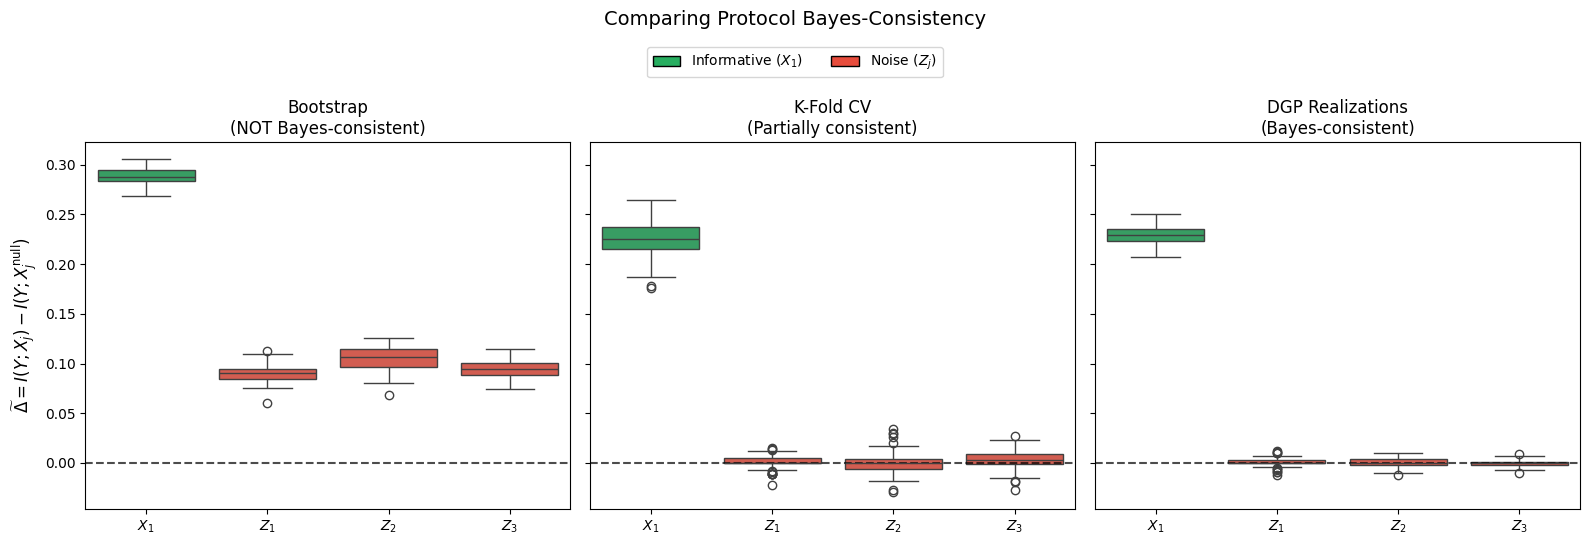

In [24]:
# Main comparison plot: All three protocols
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

protocols = ["Bootstrap", "K-Fold CV", "DGP Realizations"]
subtitles = ["NOT Bayes-consistent", "Partially consistent", "Bayes-consistent"]

for ax, protocol, subtitle in zip(axes, protocols, subtitles):
    data = results_all[results_all["protocol"] == protocol]
    
    # Color by informative vs noise
    palette = {True: "#27ae60", False: "#e74c3c"}
    
    sns.boxplot(
        data=data,
        x="feature",
        y="delta",
        hue="is_informative",
        ax=ax,
        palette=palette,
        legend=False
    )
    
    ax.axhline(y=0, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_title(f"{protocol}\n({subtitle})", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel(r"$\widetilde{\Delta} = I(Y; X_j) - I(Y; X_j^{\mathrm{null}})$", fontsize=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#27ae60", edgecolor="black", label=r"Informative ($X_1$)"),
    Patch(facecolor="#e74c3c", edgecolor="black", label=r"Noise ($Z_j$)")
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Comparing Protocol Bayes-Consistency", fontsize=14, y=1.08)
plt.tight_layout()
plt.show()


## Statistical Tests

We test if $\widetilde{\Delta} > 0$ (significantly different from zero) for noise variables under each protocol.


In [25]:
print("Statistical Tests: Is Δ > 0 for noise variables?")
print("="*75)
print(f"{'Protocol':<20} {'Feature':<10} {'Mean Δ':>10} {'t-stat':>10} {'p-value':>12}")
print("-"*75)

for protocol in ["Bootstrap", "K-Fold CV", "DGP Realizations"]:
    for fname in feature_names[1:]:  # Skip X_1 (informative)
        deltas = results_all[
            (results_all["protocol"] == protocol) & 
            (results_all["feature"] == fname)
        ]["delta"]
        
        # One-sample t-test: H0: Δ = 0
        if deltas.std() > 0:
            t_stat, p_value = stats.ttest_1samp(deltas, 0)
        else:
            t_stat, p_value = 0, 1.0
        
        # Significance marker
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        
        print(f"{protocol:<20} {fname:<10} {deltas.mean():>10.4f} {t_stat:>10.2f} {p_value:>10.4f}  {sig}")
    print()

print("\nInterpretation:")
print("- Bootstrap:   Noise shows Δ > 0 *** (SPURIOUS - correlation amplification)")
print("- K-Fold CV:   Noise shows Δ ≈ 0 or small (no amplification, but fixed D_n)")
print("- DGP:         Noise shows Δ ≈ 0 (CORRECT - true i.i.d. samples)")


Statistical Tests: Is Δ > 0 for noise variables?
Protocol             Feature        Mean Δ     t-stat      p-value
---------------------------------------------------------------------------
Bootstrap            $Z_{1}$        0.0902      70.49     0.0000  ***
Bootstrap            $Z_{2}$        0.1051      57.44     0.0000  ***
Bootstrap            $Z_{3}$        0.0950      72.49     0.0000  ***

K-Fold CV            $Z_{1}$        0.0005       0.44     0.6637  
K-Fold CV            $Z_{2}$        0.0000       0.03     0.9793  
K-Fold CV            $Z_{3}$        0.0028       1.77     0.0827  

DGP Realizations     $Z_{1}$        0.0010       1.47     0.1467  
DGP Realizations     $Z_{2}$        0.0001       0.15     0.8791  
DGP Realizations     $Z_{3}$       -0.0005      -0.86     0.3956  


Interpretation:
- Bootstrap:   Noise shows Δ > 0 *** (SPURIOUS - correlation amplification)
- K-Fold CV:   Noise shows Δ ≈ 0 or small (no amplification, but fixed D_n)
- DGP:         Noise sho

## Why Bootstrap Fails: The Mechanism

### The Problem with Bootstrap

When we bootstrap sample from $D_n = \{(x_i, y_i)\}_{i=1}^n$:

1. **Fixed sample artifacts**: The original sample $D_n$ contains finite-sample correlations between noise $Z_j$ and $Y$ by pure chance
2. **Correlation amplification**: Bootstrap resampling **preserves and amplifies** these spurious correlations (some samples appear multiple times, others are omitted)
3. **Permutation destroys more**: When we create $Z_j^{\text{null}}$ by permuting, we destroy ALL correlation (spurious + any signal)
4. **Spurious delta**: $\widetilde{\Delta} = I_{\text{spurious}} - 0 > 0$

### Why K-Fold CV is Better (but not perfect)

K-Fold CV partitions without replacement:

1. **No amplification**: Each sample appears exactly once per fold $\Rightarrow$ no correlation amplification
2. **Still fixed $D_n$**: The finite-sample artifacts in $D_n$ still exist, just not amplified
3. **Result**: $\widetilde{\Delta}$ for noise is smaller than Bootstrap, but may still be nonzero

### Why DGP Realizations Work

When we generate fresh data from the DGP:

1. **True independence**: Each $Z_j$ is generated independently of $Y$ (by construction)
2. **No artifact accumulation**: Each realization has its own sampling noise, but it averages to zero
3. **Correct estimation**: $E[\widetilde{\Delta}_{Z_j}] = I(Y; Z_j) - I(Y; Z_j^{\text{null}}) = 0 - 0 = 0$

### Mathematical Formalization

For a noise variable $Z_j \perp\!\!\!\perp Y$:

$$\text{Bootstrap: } \widetilde{\Delta}^{(b)}_{Z_j} = \underbrace{I_{D_n}(Y; Z_j)}_{\text{amplified artifact}} - \underbrace{I_{D_n}(Y; Z_j^{\text{null}})}_{\approx 0} > 0$$

$$\text{K-Fold: } \widetilde{\Delta}^{(k)}_{Z_j} = \underbrace{I_{D_n}(Y; Z_j)}_{\text{original artifact}} - \underbrace{I_{D_n}(Y; Z_j^{\text{null}})}_{\approx 0} \gtrsim 0$$

$$\text{DGP: } \widetilde{\Delta}^{(r)}_{Z_j} = \underbrace{I_{P}(Y; Z_j)}_{= 0 \text{ (true)}} - \underbrace{I_{P}(Y; Z_j^{\text{null}})}_{= 0} = 0$$


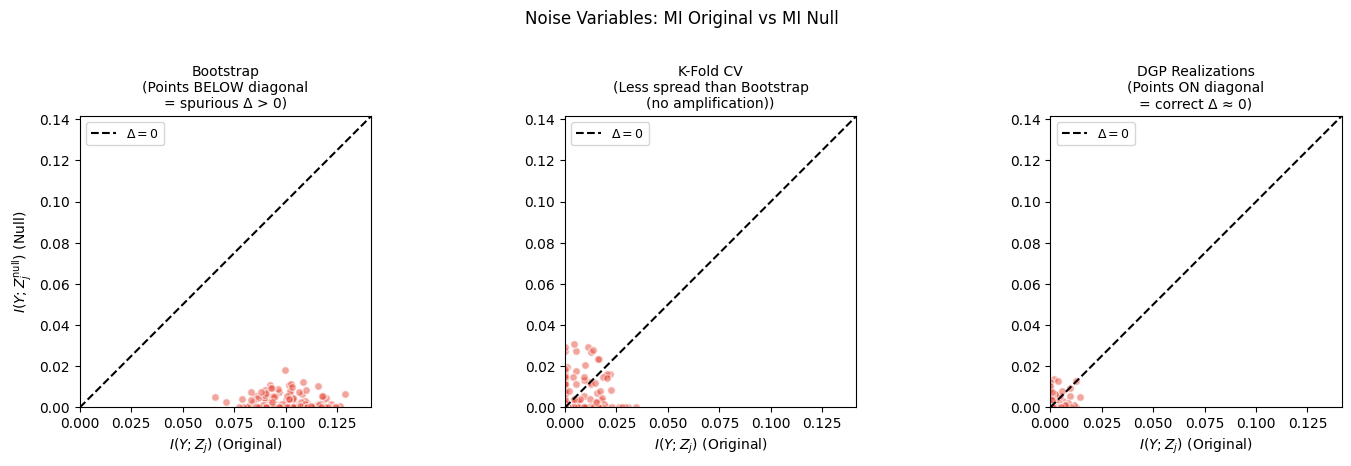

In [26]:
# Visualize the mechanism: MI_original vs MI_null for noise variables
noise_data = results_all[~results_all["is_informative"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

protocols = ["Bootstrap", "K-Fold CV", "DGP Realizations"]
annotations = [
    "Points BELOW diagonal\n= spurious Δ > 0",
    "Less spread than Bootstrap\n(no amplification)",
    "Points ON diagonal\n= correct Δ ≈ 0"
]

# Find global max for consistent axes
global_max = max(noise_data["mi_original"].max(), noise_data["mi_null"].max()) * 1.1

for ax, protocol, annot in zip(axes, protocols, annotations):
    data = noise_data[noise_data["protocol"] == protocol]
    
    ax.scatter(data["mi_original"], data["mi_null"], alpha=0.5, s=30, c="#e74c3c", edgecolor="white")
    
    # Diagonal line (y=x: would mean Δ=0)
    ax.plot([0, global_max], [0, global_max], "k--", linewidth=1.5, label=r"$\Delta = 0$")
    
    ax.set_xlabel(r"$I(Y; Z_j)$ (Original)", fontsize=10)
    ax.set_xlim(0, global_max)
    ax.set_ylim(0, global_max)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_title(f"{protocol}\n({annot})", fontsize=10)
    ax.set_aspect("equal")

axes[0].set_ylabel(r"$I(Y; Z_j^{\mathrm{null}})$ (Null)", fontsize=10)

plt.suptitle("Noise Variables: MI Original vs MI Null", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Asymptotic Check: Does K-Fold Become Bayes-Consistent as \(n\) Grows?

Bayes-consistency is an **asymptotic** statement: the estimator should converge as \(n \to \infty\).

A practical way to stress-test this is to repeat the experiment for increasing sample sizes \(n\), averaging over **fresh i.i.d. datasets** for each \(n\). If a protocol is consistent, then for **noise features** (independent of \(Y\)) we should observe:

- \(\mathbb{E}[\widetilde{\Delta}_{Z_j}] \to 0\) as \(n \to \infty\)

while the informative feature should remain bounded away from 0.



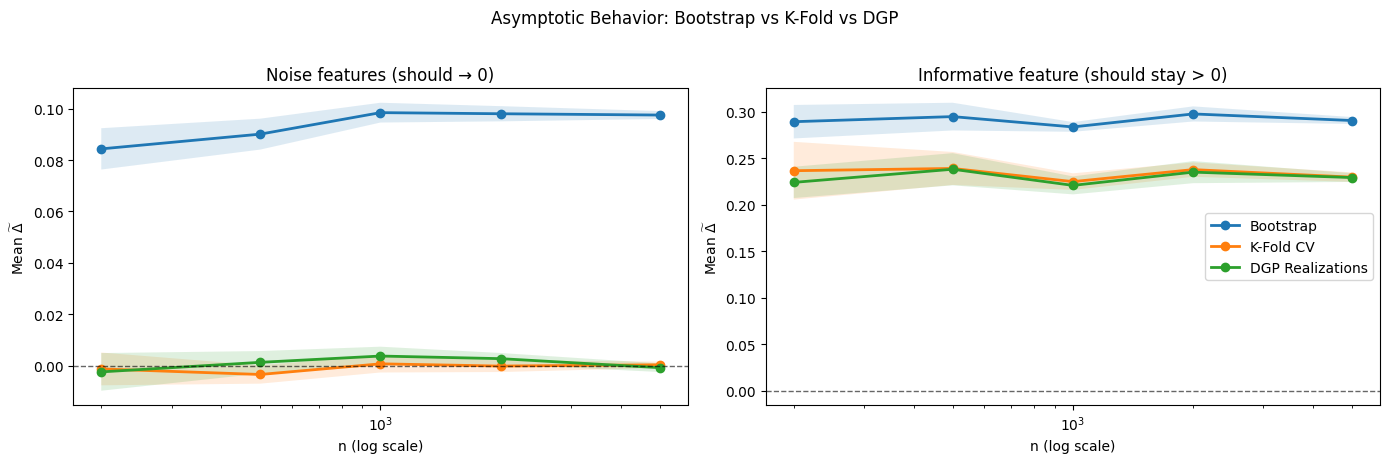

,protocol,is_informative,n,mean,std,count,se,ci_low,ci_high
0,Bootstrap,False,200,0.084365,0.022480,30,0.004104,0.076320,0.092409
1,Bootstrap,False,500,0.090102,0.016827,30,0.003072,0.084080,0.096123
2,Bootstrap,False,1000,0.098473,0.010776,30,0.001967,0.094617,0.102329
3,Bootstrap,False,2000,0.098040,0.008277,30,0.001511,0.095078,0.101002
4,Bootstrap,False,5000,0.097537,0.004297,30,0.000784,0.095999,0.099074
10,DGP Realizations,False,200,-0.002469,0.020490,30,0.003741,-0.009801,0.004863
11,DGP Realizations,False,500,0.001252,0.012260,30,0.002238,-0.003136,0.005639
12,DGP Realizations,False,1000,0.003704,0.010180,30,0.001859,0.000061,0.007347
13,DGP Realizations,False,2000,0.002685,0.006163,30,0.001125,0.000480,0.004890
14,DGP Realizations,False,5000,-0.000824,0.004707,30,0.000859,-0.002508,0.000860


In [27]:
def _swap_delta_per_feature(X, y, rng, random_state):
    """Compute swap delta per feature.

    Delta_j = I(Y; X_j) - I(Y; X_j_null), where X_j_null is a row permutation.
    """
    n_features = X.shape[1]
    deltas = np.zeros(n_features, dtype=float)

    for j in range(n_features):
        x_j = X[:, j]
        mi_original = compute_mi(x_j, y, random_state=random_state + 13 * j)

        x_j_null = create_null_copy(x_j, rng)
        mi_null = compute_mi(x_j_null, y, random_state=random_state + 13 * j + 7)

        deltas[j] = mi_original - mi_null

    return deltas


def _bootstrap_delta_mean(X, y, n_bootstrap, seed_value):
    """Estimate mean swap delta under bootstrap resampling from a fixed dataset."""
    rng = np.random.default_rng(seed_value)
    deltas_sum = np.zeros(X.shape[1], dtype=float)

    for b in range(n_bootstrap):
        idx = rng.integers(0, len(y), size=len(y))
        X_b = X[idx]
        y_b = y[idx]

        b_rng = np.random.default_rng(seed_value + 1000 * b)
        deltas_sum += _swap_delta_per_feature(
            X_b,
            y_b,
            rng=b_rng,
            random_state=seed_value + 1000 * b,
        )

    return deltas_sum / float(n_bootstrap)


def _kfold_delta_mean(X, y, n_splits, n_repeats, seed_value):
    """Estimate mean swap delta using K-Fold test folds (no replacement)."""
    deltas_sum = np.zeros(X.shape[1], dtype=float)
    n_blocks = 0

    for rep in range(n_repeats):
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed_value + rep)

        for fold_idx, (_, test_idx) in enumerate(kf.split(X)):
            X_fold = X[test_idx]
            y_fold = y[test_idx]

            fold_seed = seed_value + 10_000 * rep + 100 * fold_idx
            fold_rng = np.random.default_rng(fold_seed)
            deltas_sum += _swap_delta_per_feature(
                X_fold,
                y_fold,
                rng=fold_rng,
                random_state=fold_seed,
            )
            n_blocks += 1

    return deltas_sum / float(n_blocks)


def _single_dataset_delta(X, y, seed_value):
    """Single-dataset swap delta (one i.i.d. draw from the DGP)."""
    rng = np.random.default_rng(seed_value)
    return _swap_delta_per_feature(X, y, rng=rng, random_state=seed_value)


def run_asymptotic_sweep(
    n_values,
    p_noise,
    feature_names,
    n_datasets=10,
    n_bootstrap=10,
    n_splits=5,
    n_repeats=2,
    seed_value=42,
):
    """Run an asymptotic sweep over n, averaging over fresh i.i.d. datasets.

    This approximates the regime relevant to Bayes-consistency:
    D_n ~ P^n for each n, and we study estimator behavior as n grows.
    """
    records = []

    for n in n_values:
        for d in range(n_datasets):
            dataset_seed = seed_value + 1_000_000 * d + 17 * n
            X, y, _ = generate_dgp(n=n, p_noise=p_noise, seed=dataset_seed)

            deltas_dgp = _single_dataset_delta(X, y, seed_value=dataset_seed + 1)
            deltas_kfold = _kfold_delta_mean(
                X,
                y,
                n_splits=n_splits,
                n_repeats=n_repeats,
                seed_value=dataset_seed + 2,
            )
            deltas_boot = _bootstrap_delta_mean(
                X,
                y,
                n_bootstrap=n_bootstrap,
                seed_value=dataset_seed + 3,
            )

            for j, fname in enumerate(feature_names):
                is_informative = j == 0

                records.append(
                    {
                        "n": int(n),
                        "dataset": int(d),
                        "protocol": "DGP Realizations",
                        "feature": fname,
                        "is_informative": is_informative,
                        "delta": float(deltas_dgp[j]),
                    }
                )
                records.append(
                    {
                        "n": int(n),
                        "dataset": int(d),
                        "protocol": "K-Fold CV",
                        "feature": fname,
                        "is_informative": is_informative,
                        "delta": float(deltas_kfold[j]),
                    }
                )
                records.append(
                    {
                        "n": int(n),
                        "dataset": int(d),
                        "protocol": "Bootstrap",
                        "feature": fname,
                        "is_informative": is_informative,
                        "delta": float(deltas_boot[j]),
                    }
                )

    return pd.DataFrame.from_records(records)


# Run the sweep (keep settings modest to avoid long runtimes in notebooks)
n_values = [200, 500, 1000, 2000, 5000]
results_asymptotic = run_asymptotic_sweep(
    n_values=n_values,
    p_noise=p_noise,
    feature_names=feature_names,
    n_datasets=10,
    n_bootstrap=10,
    n_splits=5,
    n_repeats=2,
    seed_value=seed,
)

# Aggregate: mean +/- 95% normal CI across datasets
summary_asymptotic = (
    results_asymptotic.groupby(["protocol", "is_informative", "n"], as_index=False)["delta"]
    .agg(mean="mean", std="std", count="count")
)
summary_asymptotic["se"] = summary_asymptotic["std"] / np.sqrt(summary_asymptotic["count"])
summary_asymptotic["ci_low"] = summary_asymptotic["mean"] - 1.96 * summary_asymptotic["se"]
summary_asymptotic["ci_high"] = summary_asymptotic["mean"] + 1.96 * summary_asymptotic["se"]

# Plot: informative vs noise convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)

panels = [
    (False, "Noise features (should \u2192 0)"),
    (True, "Informative feature (should stay > 0)"),
]

for ax, (flag, title) in zip(axes, panels):
    data = summary_asymptotic[summary_asymptotic["is_informative"] == flag]

    for protocol in ["Bootstrap", "K-Fold CV", "DGP Realizations"]:
        d = data[data["protocol"] == protocol].sort_values("n")
        ax.plot(d["n"], d["mean"], marker="o", linewidth=2, label=protocol)
        ax.fill_between(d["n"], d["ci_low"], d["ci_high"], alpha=0.15)

    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("n (log scale)")
    ax.set_ylabel(r"Mean $\widetilde{\Delta}$")

axes[1].legend(loc="best")
plt.suptitle("Asymptotic Behavior: Bootstrap vs K-Fold vs DGP", y=1.02)
plt.tight_layout()
plt.show()

summary_asymptotic.sort_values(["is_informative", "protocol", "n"]).head(12)



## Conclusions

### Key Findings

| Protocol | Bayes-Consistent? | Noise Δ | Why |
|----------|-------------------|---------|-----|
| **Bootstrap** | NO | $> 0$ *** | Amplifies spurious correlations via resampling |
| **K-Fold CV** | Partially | $\gtrsim 0$ | No amplification, but fixed $D_n$ artifacts remain |
| **DGP Realizations** | YES | $\approx 0$ | True i.i.d. samples, no artifacts |

### Implications for Epistemic Framework

The choice of experimental protocol is **epistemically critical**:

- A non-Bayes-consistent protocol can produce "evidence" that a variable belongs to $\mathcal{I}$ (informative set) when it actually belongs to $\mathcal{F}^c$ (complement of causal set, i.e., noise)

- This violates the **epistemic guarantee** that $\widetilde{\Delta} > 0 \Rightarrow X_j \in \mathcal{I}$

### Practical Recommendations

| Scenario | Recommended Protocol |
|----------|---------------------|
| **Synthetic data** (DGP known) | Multiple DGP realizations |
| **Real data** (DGP unknown) | K-Fold CV (avoid bootstrap for informativity tests) |
| **Variance estimation** | Bootstrap is OK for confidence intervals, not for null hypothesis testing |

### Why K-Fold is Better than Bootstrap for Real Data

When the true DGP is unknown:
- K-Fold CV avoids the **correlation amplification** problem of bootstrap
- It uses **all data exactly once** per fold (no duplicates, no omissions)
- The finite-sample artifacts in $D_n$ are **not amplified**, only present at their original level


In [28]:
# Save results
results_all.to_csv("bayes_consistency_comparison.csv", index=False)
print("Results saved to 'bayes_consistency_comparison.csv'")


Results saved to 'bayes_consistency_comparison.csv'
